**Question a)**

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [3]:
k = 3.2e-13
N = 30000.0
G = 30.0
CL_star = 6.0
Vm = 16.0
Ks = 7.0
KCL = 0.3
YOS = 5.0
YPS = 1.5

S0 = 100.0
CL0 = 6.0
P0 = 0.0

y0 = [S0, CL0, P0]

CL_lim = 3 * KCL

kLa = k * N**3 * np.sqrt(G)

print(f"kLa = {kLa:.3f} h^-1")
print(f"Oxygen limitation threshold = {CL_lim:.3f} mg/L")

kLa = 47.323 h^-1
Oxygen limitation threshold = 0.900 mg/L


In [4]:
def reactor_odes(t, y):
    S, CL, P = y
    
    S = max(S, 0)
    CL = max(CL, 0)
    
    rs = Vm * (S / (Ks + S)) * (CL / (KCL + CL))

    dSdt = -rs
    dCLdt = kLa * (CL_star - CL) - YOS * rs
    dPdt = YPS * rs
    
    return [dSdt, dCLdt, dPdt]

In [5]:
t_span = (0, 20)
t_eval = np.linspace(t_span[0], t_span[1], 1000)

sol = solve_ivp(
    reactor_odes,
    t_span,
    y0,
    t_eval=t_eval,
    method="BDF",
    rtol=1e-8,
    atol=1e-10
)

t = sol.t
S = sol.y[0]
CL = sol.y[1]
P = sol.y[2]

CL_min = np.min(CL)

print(f"Minimum CL = {CL_min:.3f} mg/L")

if CL_min > CL_lim:
    print("The system is NOT oxygen limited.")
else:
    print("The system is oxygen limited.")

Minimum CL = 4.521 mg/L
The system is NOT oxygen limited.


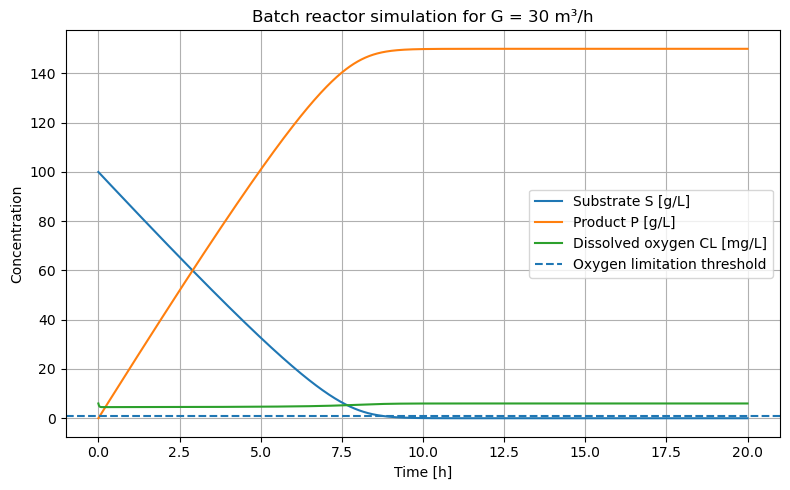

In [6]:
plt.figure(figsize=(8, 5))

plt.plot(t, S, label="Substrate S [g/L]")
plt.plot(t, P, label="Product P [g/L]")
plt.plot(t, CL, label="Dissolved oxygen CL [mg/L]")

plt.axhline(CL_lim, linestyle="--", label="Oxygen limitation threshold")

plt.xlabel("Time [h]")
plt.ylabel("Concentration")
plt.title("Batch reactor simulation for G = 30 m³/h")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Question b)**

In [7]:
from scipy.optimize import brentq

In [8]:
def simulate_for_G(G_value, t_end=60):
    """
    Simulates the batch reactor for a given aeration rate G.
    Returns time, S, CL, P, minimum CL, and kLa.
    """
    
    kLa_value = k * N**3 * np.sqrt(G_value)
    
    def reactor_odes_G(t, y):
        S, CL, P = y
        
        S = max(S, 0)
        CL = max(CL, 0)
        
        rs = Vm * (S / (Ks + S)) * (CL / (KCL + CL))
        
        dSdt = -rs
        dCLdt = kLa_value * (CL_star - CL) - YOS * rs
        dPdt = YPS * rs
        
        return [dSdt, dCLdt, dPdt]
    
    t_eval = np.linspace(0, t_end, 1000)
    
    sol = solve_ivp(
        reactor_odes_G,
        (0, t_end),
        y0,
        t_eval=t_eval,
        method="BDF",
        rtol=1e-8,
        atol=1e-10
    )
    
    t = sol.t
    S = sol.y[0]
    CL = sol.y[1]
    P = sol.y[2]
    
    CL_min = np.min(CL)
    
    return t, S, CL, P, CL_min, kLa_value

In [12]:
G_values = np.linspace(0.1, 30, 300)

CL_min_values = []

for G_value in G_values:
    t, S, CL, P, CL_min, kLa_value = simulate_for_G(G_value)
    CL_min_values.append(CL_min)

CL_min_values = np.array(CL_min_values)

In [13]:
def oxygen_limitation_function(G_value):
    _, _, _, _, CL_min, _ = simulate_for_G(G_value)
    return CL_min - CL_lim

G_critical = brentq(oxygen_limitation_function, 0.1, 30)

_, _, _, _, CL_min_critical, kLa_critical = simulate_for_G(G_critical)

print(f"Critical aeration rate G = {G_critical:.3f} m^3/h")
print(f"Minimum CL at this G = {CL_min_critical:.3f} mg/L")
print(f"kLa at this G = {kLa_critical:.3f} h^-1")

Critical aeration rate G = 1.609 m^3/h
Minimum CL at this G = 0.900 mg/L
kLa at this G = 10.959 h^-1


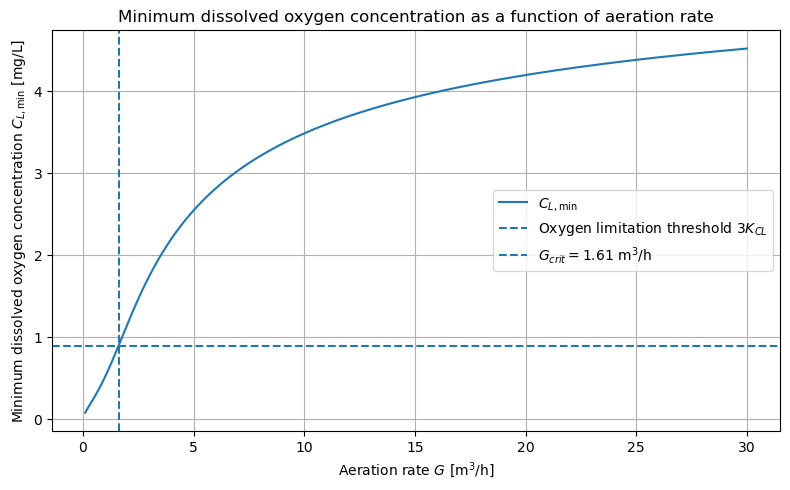

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(G_values, CL_min_values, label=r"$C_{L,\min}$")
plt.axhline(CL_lim, linestyle="--", label=r"Oxygen limitation threshold $3K_{CL}$")
plt.axvline(G_critical, linestyle="--", label=fr"$G_{{crit}} = {G_critical:.2f}$ m$^3$/h")

plt.xlabel(r"Aeration rate $G$ [m$^3$/h]")
plt.ylabel(r"Minimum dissolved oxygen concentration $C_{L,\min}$ [mg/L]")
plt.title(r"Minimum dissolved oxygen concentration as a function of aeration rate")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("ex1b_CLmin_vs_G.png", dpi=300, bbox_inches="tight")

plt.show()

**Question c)**

In [15]:
G_c = G_critical

def simulate_for_G_and_Vm(G_value, Vm_value, t_end=60):
    """
    Simulates the batch reactor for a given aeration rate G and Vm.
    Returns time, S, CL, P, reaction rate rs, minimum CL, kLa.
    """
    
    kLa_value = k * N**3 * np.sqrt(G_value)
    
    def reactor_odes_G_Vm(t, y):
        S, CL, P = y
        
        S = max(S, 0)
        CL = max(CL, 0)
        
        rs = Vm_value * (S / (Ks + S)) * (CL / (KCL + CL))
        
        dSdt = -rs
        dCLdt = kLa_value * (CL_star - CL) - YOS * rs
        dPdt = YPS * rs
        
        return [dSdt, dCLdt, dPdt]
    
    t_eval = np.linspace(0, t_end, 2000)
    
    sol = solve_ivp(
        reactor_odes_G_Vm,
        (0, t_end),
        y0,
        t_eval=t_eval,
        method="BDF",
        rtol=1e-8,
        atol=1e-10
    )
    
    t = sol.t
    S = sol.y[0]
    CL = sol.y[1]
    P = sol.y[2]
    
    rs = Vm_value * (S / (Ks + S)) * (CL / (KCL + CL))
    
    CL_min = np.min(CL)
    
    return t, S, CL, P, rs, CL_min, kLa_value

In [16]:
t_1, S_1, CL_1, P_1, rs_1, CL_min_1, kLa_1 = simulate_for_G_and_Vm(G_c, Vm)

Vm_half = Vm / 2
t_2, S_2, CL_2, P_2, rs_2, CL_min_2, kLa_2 = simulate_for_G_and_Vm(G_c, Vm_half)

In [17]:
def find_steady_state_time(t, S, P, threshold=1e-3):
    """
    Finds the first time where S is below a small threshold.
    Returns t_ss and P_ss.
    """
    
    indices = np.where(S <= threshold)[0]
    
    if len(indices) > 0:
        idx_ss = indices[0]
    else:
        idx_ss = -1
    
    t_ss = t[idx_ss]
    P_ss = P[idx_ss]
    
    return t_ss, P_ss

t_ss_1, P_ss_1 = find_steady_state_time(t_1, S_1, P_1)
t_ss_2, P_ss_2 = find_steady_state_time(t_2, S_2, P_2)

In [18]:
rP_avg_1 = (P_ss_1 - P0) / t_ss_1
rP_avg_2 = (P_ss_2 - P0) / t_ss_2

ratio = rP_avg_2 / rP_avg_1

print("Case 1: Vm = Vm")
print(f"Vm = {Vm:.2f} g/L/h")
print(f"t_ss = {t_ss_1:.3f} h")
print(f"P_ss = {P_ss_1:.3f} g/L")
print(f"Average product formation rate = {rP_avg_1:.3f} g/L/h")
print(f"Minimum CL = {CL_min_1:.3f} mg/L")

if CL_min_1 <= CL_lim:
    print("The reaction is oxygen limited.")
else:
    print("The reaction is NOT oxygen limited.")

print("\nCase 2: Vm = Vm/2")
print(f"Vm = {Vm_half:.2f} g/L/h")
print(f"t_ss = {t_ss_2:.3f} h")
print(f"P_ss = {P_ss_2:.3f} g/L")
print(f"Average product formation rate = {rP_avg_2:.3f} g/L/h")
print(f"Minimum CL = {CL_min_2:.3f} mg/L")

if CL_min_2 <= CL_lim:
    print("The reaction is oxygen limited.")
else:
    print("The reaction is NOT oxygen limited.")

print("\nComparison")
print(f"Ratio rP_avg(Vm/2) / rP_avg(Vm) = {ratio:.3f}")
print(f"Percentage decrease = {(1-ratio)*100:.1f}%")

Case 1: Vm = Vm
Vm = 16.00 g/L/h
t_ss = 13.387 h
P_ss = 149.999 g/L
Average product formation rate = 11.205 g/L/h
Minimum CL = 0.900 mg/L
The reaction is oxygen limited.

Case 2: Vm = Vm/2
Vm = 8.00 g/L/h
t_ss = 24.372 h
P_ss = 149.999 g/L
Average product formation rate = 6.154 g/L/h
Minimum CL = 2.916 mg/L
The reaction is NOT oxygen limited.

Comparison
Ratio rP_avg(Vm/2) / rP_avg(Vm) = 0.549
Percentage decrease = 45.1%


In [20]:
print("Question c results")
print("-" * 60)

print(f"{'Case':<10} {'Vm [g/L/h]':<15} {'t_ss [h]':<12} {'P_ss [g/L]':<15} {'rP_avg [g/L/h]':<20} {'CL_min [mg/L]':<15} {'O2 limited?'}")

print(f"{'Vm':<10} {Vm:<15.3f} {t_ss_1:<12.3f} {P_ss_1:<15.3f} {rP_avg_1:<20.3f} {CL_min_1:<15.3f} {CL_min_1 <= CL_lim}")

print(f"{'Vm/2':<10} {Vm_half:<15.3f} {t_ss_2:<12.3f} {P_ss_2:<15.3f} {rP_avg_2:<20.3f} {CL_min_2:<15.3f} {CL_min_2 <= CL_lim}")

print("-" * 60)
print(f"Ratio rP_avg(Vm/2) / rP_avg(Vm) = {ratio:.3f}")
print(f"Percentage decrease = {(1-ratio)*100:.1f}%")

Question c results
------------------------------------------------------------
Case       Vm [g/L/h]      t_ss [h]     P_ss [g/L]      rP_avg [g/L/h]       CL_min [mg/L]   O2 limited?
Vm         16.000          13.387       149.999         11.205               0.900           True
Vm/2       8.000           24.372       149.999         6.154                2.916           False
------------------------------------------------------------
Ratio rP_avg(Vm/2) / rP_avg(Vm) = 0.549
Percentage decrease = 45.1%


**Question d)**

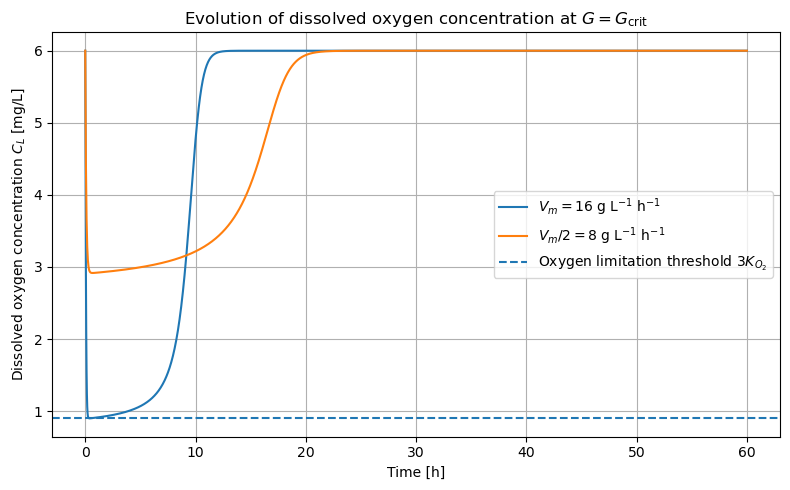

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(t_1, CL_1, label=r"$V_m = 16$ g L$^{-1}$ h$^{-1}$")
plt.plot(t_2, CL_2, label=r"$V_m/2 = 8$ g L$^{-1}$ h$^{-1}$")

plt.axhline(CL_lim, linestyle="--", label=r"Oxygen limitation threshold $3K_{O_2}$")

plt.xlabel("Time [h]")
plt.ylabel(r"Dissolved oxygen concentration $C_L$ [mg/L]")
plt.title(r"Evolution of dissolved oxygen concentration at $G = G_{\mathrm{crit}}$")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("ex1d_CL_vs_time_Vm_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

In [23]:
print("Question d results")
print("-" * 50)
print(f"For Vm = {Vm:.1f} g/L/h:")
print(f"Minimum CL = {CL_min_1:.3f} mg/L")
print(f"Oxygen limitation threshold = {CL_lim:.3f} mg/L")
print(f"Oxygen limited? {CL_min_1 <= CL_lim}")

print()

print(f"For Vm/2 = {Vm_half:.1f} g/L/h:")
print(f"Minimum CL = {CL_min_2:.3f} mg/L")
print(f"Oxygen limitation threshold = {CL_lim:.3f} mg/L")
print(f"Oxygen limited? {CL_min_2 <= CL_lim}")

Question d results
--------------------------------------------------
For Vm = 16.0 g/L/h:
Minimum CL = 0.900 mg/L
Oxygen limitation threshold = 0.900 mg/L
Oxygen limited? True

For Vm/2 = 8.0 g/L/h:
Minimum CL = 2.916 mg/L
Oxygen limitation threshold = 0.900 mg/L
Oxygen limited? False
